# Example usage of `vfp` with refnx

To demonstrate the `vfp` we'll model some NR data taken with a Si substrate. 

Two NR contrasts were taken in a solid-liquid cell with dodecane ($\mathrm{C}_{12}\mathrm{H}_{26}$ \& $\mathrm{C}_{12}\mathrm{D}_{26}$).

Two other contrasts were taken with the same substrate with solutions of glycerol monooleate, a surfactant, in $\mathrm{C}_{12}\mathrm{H}_{26}$ \& $\mathrm{C}_{12}\mathrm{D}_{26}$.

In [21]:
import pathlib
import os
import matplotlib.pyplot as plt

from refnx.analysis import GlobalObjective, Parameter, Objective, CurveFitter
from refnx.reflect import ReflectModel, SLD
from refnx.dataset import ReflectDataset

import vfp

In [22]:
dataset_dir = pathlib.Path(vfp.__path__[0]).parents[1] / 'docs'
with os.scandir(dataset_dir) as files:
    nr_data_fps = [file.name for file in files if file.name.startswith('IvsQ')]
    data_fp_dict = {'ddod' : nr_data_fps[0],
                    'hdod' : nr_data_fps[1],
                    'hdod_GMO' : nr_data_fps[2],
                    'ddod_GMO' : nr_data_fps[3]}

In [23]:
Si_dd_data = ReflectDataset(dataset_dir / data_fp_dict['ddod'])
Si_hd_data = ReflectDataset(dataset_dir / data_fp_dict['hdod'])
Si_hd_GMO_data = ReflectDataset(dataset_dir / data_fp_dict['hdod_GMO'])
Si_dd_GMO_data = ReflectDataset(dataset_dir / data_fp_dict['ddod_GMO'])

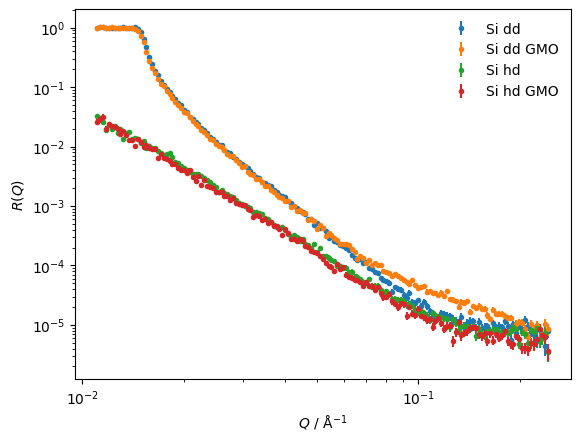

In [24]:
plt.errorbar(x=Si_dd_data.x, 
             y=Si_dd_data.y, 
             yerr=Si_dd_data.y_err, 
             marker='.', 
             linestyle='None',
             label=r'Si dd')
plt.errorbar(x=Si_dd_GMO_data.x, 
             y=Si_dd_GMO_data.y, 
             yerr=Si_dd_GMO_data.y_err, 
             marker='.', 
             linestyle='None',
             label=r'Si dd GMO')
plt.errorbar(x=Si_hd_data.x, 
             y=Si_hd_data.y, 
             yerr=Si_hd_data.y_err, 
             marker='.', 
             linestyle='None',
             label=r'Si hd')
plt.errorbar(x=Si_hd_GMO_data.x, 
             y=Si_hd_GMO_data.y, 
             yerr=Si_hd_GMO_data.y_err, 
             marker='.', 
             linestyle='None',
             label=r'Si hd GMO')
plt.legend(frameon=False)
plt.xscale('log') 
plt.yscale('log')
plt.xlabel(r'$Q$ / $\mathrm{\AA{}}^{-1}$')
plt.ylabel(r'$R\left(Q\right)$')
plt.show()

# The model
We'll model the bare Si data with a fronting of Si, and layer of $\mathrm{SiO}_{2}$ and a solvent backing.

The SLDs of the materials will be fixed but we'll model the thickness of the $\mathrm{SiO}_{2}$ and the roughness of the interfaces between the materials.

For those contrasts with GMO, we'll model a GMO layer with a fixed SLD of GMO = $0.21 \times 10^{-6} \mathrm{\AA}^{-2}$, a varying solvation, thickness and roughness.

There will be the same interface width between $\mathrm{SiO}_{2}$ and the solvent and between $\mathrm{SiO}_{2}$ and GMO.


In [25]:
Si = SLD(2.07, name='Si')
SiO2 = SLD(3.47, name='SiO2')
GMO = SLD(0.21, name='GMO')

hdod = SLD(-0.46, name='hdod')
ddod = SLD(6.7, name='ddod')

In [26]:
# define thickness and roughness parameters.
SiO2_thick = Parameter(20, name='SiO2_thick', vary=True, bounds=(1, 30))
GMO_thick = Parameter(20, name='GMO_thick', vary=True, bounds=(1, 30))

Si_SiO2_rough = Parameter(3, name='Si_SiO2_rough', vary=True, bounds=(1, 10))
SiO2_solv_rough = Parameter(5, name='SiO2_solv_rough', vary=True, bounds=(1, 10))

SiO2_GMO_rough = Parameter(constraint=SiO2_solv_rough)
GMO_solv_rough = Parameter(5, name='GMO_solv_rough', vary=True, bounds=(1, 10))

GMO_vf = Parameter(1, name='GMO_vf', vary=True, bounds=(0, 1))

In [27]:
# define the SLDs of the materials in two lists for the two contrasts.
dd_nSLDs = [Si.real,
            SiO2.real,
            ddod.real]

hd_nSLDs = [Si.real,
            SiO2.real,
            hdod.real]

dd_GMO_nSLDs = [Si.real,
                SiO2.real,
                GMO.real * GMO_vf + ddod.real * (1-GMO_vf),
                ddod.real]

hd_GMO_nSLDs = [Si.real,
                SiO2.real,
                GMO.real * GMO_vf + hdod.real * (1-GMO_vf),
                hdod.real]

# define the thicknesses of the all layers, including the fronting but not the backing.
list_of_thicknesses_bare = [0, SiO2_thick]
list_of_thicknesses_GMO = [0, SiO2_thick, GMO_thick]
# define the width the of the interfaces between the materials.
list_of_roughnesses_bare = [Si_SiO2_rough, SiO2_solv_rough]
list_of_roughnesses_GMO = [Si_SiO2_rough, SiO2_GMO_rough, GMO_solv_rough]

# use the list of SLDs, thicknesses and roughnesses to define refnxVFP objects.
dd_vfp_bare = vfp.refnxVFP(nucSLDs=dd_nSLDs,
                           thicknesses=list_of_thicknesses_bare,
                           roughnesses=list_of_roughnesses_bare)

hd_vfp_bare = vfp.refnxVFP(nucSLDs=hd_nSLDs,
                           thicknesses=list_of_thicknesses_bare,
                           roughnesses=list_of_roughnesses_bare)

dd_vfp_GMO = vfp.refnxVFP(nucSLDs=dd_GMO_nSLDs,
                           thicknesses=list_of_thicknesses_GMO,
                           roughnesses=list_of_roughnesses_GMO)

hd_vfp_GMO = vfp.refnxVFP(nucSLDs=hd_GMO_nSLDs,
                           thicknesses=list_of_thicknesses_GMO,
                           roughnesses=list_of_roughnesses_GMO)

C:\Users\sandy\OneDrive\PDRA - Job 2021-2024\VFP\src\vfp\basevfp.py:520: UserWarning: Pass nucSLD parameters that are only part of a parameter operation 
                                (i.e f(p1, p2) = p1 + p2) to the auxiliary parameters argument of the objective.
  warnings.warn(


In [28]:
# we can get a list of the parameters that have been passed 
# to the vfp which have been automatically recognised by refnx.
# notice that the GMO_vf parameter hasn't be recognised so we have to add it later.

print(dd_vfp_GMO.parameters)

________________________________________________________________________________
Parameters:   'refnx VFP'  
<Parameter:'refnx VFP - Layer0 - thick', value=0  (fixed) , bounds=[-inf, inf]>
<Parameter: 'SiO2_thick'  , value=20          , bounds=[1.0, 30.0]>
<Parameter:  'GMO_thick'  , value=20          , bounds=[1.0, 30.0]>
<Parameter:'Si_SiO2_rough', value=3          , bounds=[1.0, 10.0]>
<Parameter:     None      , value=5          , bounds=[-inf, inf], constraint=<Parameter:'SiO2_solv_rough', value=5          , bounds=[1.0, 10.0]>>
<Parameter:'GMO_solv_rough', value=5          , bounds=[1.0, 10.0]>
<Parameter:  'Si - sld'   , value=2.07  (fixed) , bounds=[-inf, inf]>
<Parameter: 'SiO2 - sld'  , value=3.47  (fixed) , bounds=[-inf, inf]>
<Parameter: 'ddod - sld'  , value=6.7  (fixed) , bounds=[-inf, inf]>


In [29]:
# the refnxVFP objects are refnx Component objects so can be placed in a refnx structure.
dd_struc = Si | dd_vfp_bare | ddod
hd_struc = Si | hd_vfp_bare | hdod
dd_GMO_struc = Si | dd_vfp_GMO | ddod
hd_GMO_struc = Si | hd_vfp_GMO | hdod

In [30]:
# define instrument / nuisance parameters
dd_scale = Parameter(1, name='dd_scale', vary=True, bounds=(0.8, 1.2))
hd_scale = Parameter(1, name='hd_scale', vary=True, bounds=(0.8, 1.2))
dd_GMO_scale = Parameter(1, name='dd_GMO_scale', vary=True, bounds=(0.8, 1.2))
hd_GMO_scale = Parameter(1, name='hd_GMO_scale', vary=True, bounds=(0.8, 1.2))

dd_bkg = Parameter(1e-6, name='dd_bkg', vary=True, bounds=(1e-10, 1e-4))
hd_bkg = Parameter(1e-6, name='hd_bkg', vary=True, bounds=(1e-10, 1e-4))
dd_GMO_bkg = Parameter(1e-6, name='dd_GMO_bkg', vary=True, bounds=(1e-10, 1e-4))
hd_GMO_bkg = Parameter(1e-6, name='hd_GMO_bkg', vary=True, bounds=(1e-10, 1e-4))

In [32]:
dd_model = ReflectModel(structure=dd_struc, scale=dd_scale, bkg=dd_bkg)
hd_model = ReflectModel(structure=hd_struc, scale=hd_scale, bkg=hd_bkg)
dd_GMO_model = ReflectModel(structure=dd_GMO_struc, scale=dd_GMO_scale, bkg=dd_GMO_bkg)
hd_GMO_model = ReflectModel(structure=hd_GMO_struc, scale=hd_GMO_scale, bkg=hd_GMO_bkg)

dd_obj = Objective(model=dd_model, data=Si_dd_data)
hd_obj = Objective(model=hd_model, data=Si_hd_data)
dd_GMO_obj = Objective(model=dd_GMO_model, data=Si_dd_GMO_data, auxiliary_params=[GMO_vf])
hd_GMO_obj = Objective(model=hd_GMO_model, data=Si_hd_GMO_data, auxiliary_params=[GMO_vf])

# as the SLD of the GMO layer is a product of
glob_obj = GlobalObjective(objectives=[dd_obj, hd_obj, dd_GMO_obj, hd_GMO_obj])

In [34]:
# glob obj now has gmo_vf.
print(glob_obj.parameters)

________________________________________________________________________________
Parameters: 'global fitting parameters'
________________________________________________________________________________
Parameters:       ''       
________________________________________________________________________________
Parameters: 'instrument parameters'
<Parameter:  'dd_scale'   , value=1          , bounds=[0.8, 1.2]>
<Parameter:   'dd_bkg'    , value=1e-06          , bounds=[1e-10, 0.0001]>
<Parameter:'dq - resolution', value=5  (fixed) , bounds=[-inf, inf]>
<Parameter:  'q_offset'   , value=0  (fixed) , bounds=[-inf, inf]>
________________________________________________________________________________
Parameters: 'Structure - ' 
________________________________________________________________________________
Parameters:      'Si'      
<Parameter: 'Si - thick'  , value=0  (fixed) , bounds=[-inf, inf]>
________________________________________________________________________________
Parameters

# Optimisation
We'll do a differential evolution optimisation to maximise the likelihood for a quick example.

In [36]:
fitter = CurveFitter(objective=glob_obj)
fitter.fit(method='differential_evolution', workers=-1)

0it [00:00, ?it/s]c:\Users\sandy\OneDrive\PDRA - Job 2021-2024\VFP\.venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
-4027.9929901186088: : 33it [07:25, 13.49s/it]


KeyboardInterrupt: 

# plot the data & model

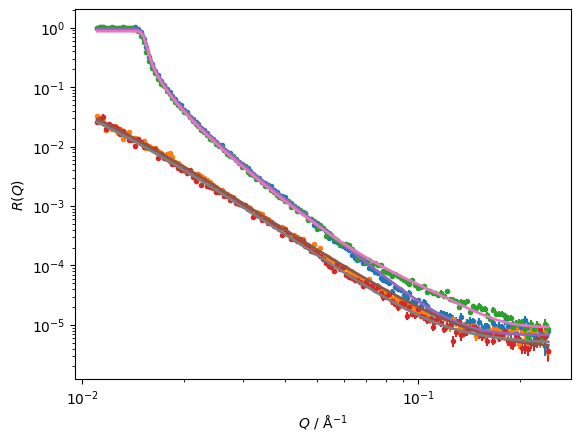

In [37]:
plt.errorbar(x=Si_dd_data.x, y=Si_dd_data.y, yerr=Si_dd_data.y_err, marker='.', linestyle='None')
plt.errorbar(x=Si_hd_data.x, y=Si_hd_data.y, yerr=Si_hd_data.y_err, marker='.', linestyle='None')
plt.errorbar(x=Si_dd_GMO_data.x, y=Si_dd_GMO_data.y, yerr=Si_dd_GMO_data.y_err, marker='.', linestyle='None')
plt.errorbar(x=Si_hd_GMO_data.x, y=Si_hd_GMO_data.y, yerr=Si_hd_GMO_data.y_err, marker='.', linestyle='None')
plt.plot(glob_obj.objectives[0].data.x, glob_obj.objectives[0].generative(), zorder=5, linewidth=2)
plt.plot(glob_obj.objectives[1].data.x, glob_obj.objectives[1].generative(), zorder=6, linewidth=2)
plt.plot(glob_obj.objectives[2].data.x, glob_obj.objectives[2].generative(), zorder=7, linewidth=2)
plt.plot(glob_obj.objectives[3].data.x, glob_obj.objectives[3].generative(), zorder=8, linewidth=2)
plt.xscale('log') 
plt.yscale('log')
plt.xlabel(r'$Q$ / $\mathrm{\AA{}}^{-1}$')
plt.ylabel(r'$R\left(Q\right)$')
plt.show()

# Plot the structure of the vfp

Use the vfp's plot method to plot the SLD, volume fraction profile and a stochastic simulation of the interface.

In the current implementation, there is no way to plot the posterior, but this will be added.

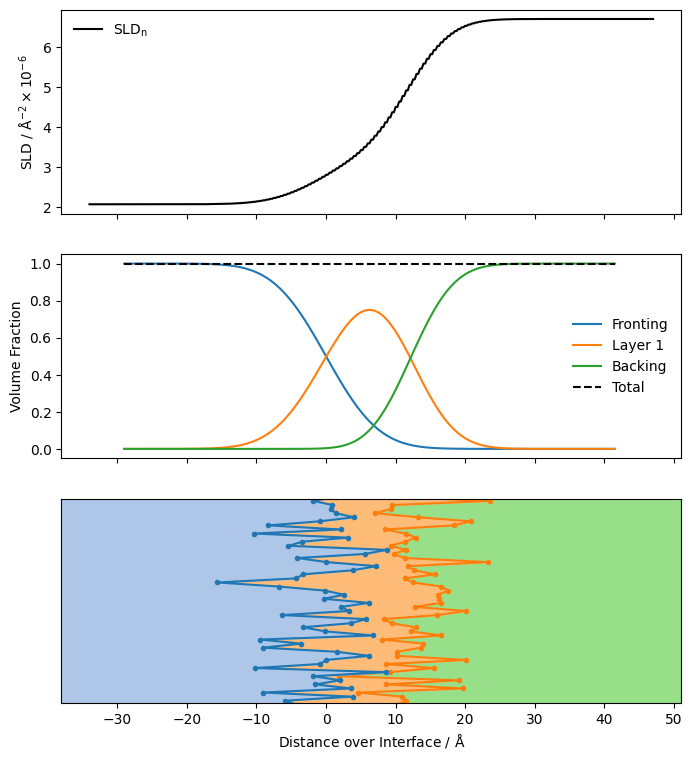

In [38]:
dd_vfp_bare.plot() # equivalent to glob_obj.objectives[0].model.structure.components[1].plot()
plt.show()

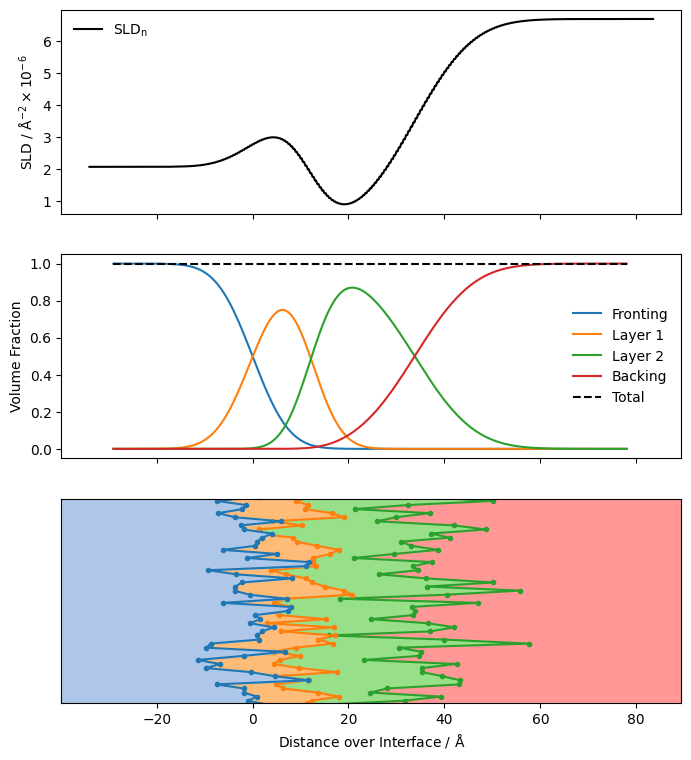

In [39]:
dd_vfp_GMO.plot() # equivalent to glob_obj.objectives[2].model.structure.components[1].plot()
plt.show()